This is a notebook for computing deep foundation axial geotechnical capacity with soil strata. <br>
Author: Zhiyan Jiang [(linkedin.com/in/zhiyanjiang)](http://www.linkedin.com/in/zhiyanjiang)

In [1]:
%load_ext autoreload
%autoreload 2

Built-in and third-party libraries

In [2]:

import yaml

Local libraries

In [3]:
from nb_utilis import find_project_root

from deep_foundation_bearing_capacity.cross_sections.cross_sections import CircularSection
from deep_foundation_bearing_capacity.factor_of_safety.factor_of_safety import FactorOfSafetyDeepFoundation
from deep_foundation_bearing_capacity.foundation.deep_foundation import DeepFoundation
from deep_foundation_bearing_capacity.foundation.foundation_material import FoundationConcrete
from deep_foundation_bearing_capacity.geomaterials.layer import Layer
from deep_foundation_bearing_capacity.geomaterials.soil import Soil
from deep_foundation_bearing_capacity.segments.segments import Segment
from deep_foundation_bearing_capacity.segments.unit_resistance import (
    SideResistance,
    SideResistanceContext,
    SoilEndResistance,
)

Project environment setup

In [4]:
PROJECT_ROOT = find_project_root()


Read rock material parameters from YAML

In [5]:
# Read soil parameters from YAML
with open(PROJECT_ROOT/"data/soil_params.yaml") as f:
    soils_dict = yaml.safe_load(f)

soil_list = []
for soil_dict in soils_dict:
    soil_dict = Soil.from_dict(soil_dict)
    soil_list.append(soil_dict)

    soil_dict.display_properties()
    print()

soil_index is: 0
unit_weight is: 120.0
cohesion is: 0.0
friction_angle is: 30.0
n60 is: 5

soil_index is: 1
unit_weight is: 120.0
cohesion is: 500.0
friction_angle is: 0.0
n60 is: 6

soil_index is: 2
unit_weight is: 115.0
cohesion is: 0.0
friction_angle is: 30.0
n60 is: 10

soil_index is: 3
unit_weight is: 115.0
cohesion is: 2000.0
friction_angle is: 0.0
n60 is: 6

soil_index is: 4
unit_weight is: 130.0
cohesion is: 0.0
friction_angle is: 30.0
n60 is: 19

soil_index is: 5
unit_weight is: 130.0
cohesion is: 4000.0
friction_angle is: 0.0
n60 is: 19

soil_index is: 6
unit_weight is: 130.0
cohesion is: 0.0
friction_angle is: 30.0
n60 is: 26

soil_index is: 7
unit_weight is: 130.0
cohesion is: 200.0
friction_angle is: 0.0
n60 is: 26

soil_index is: 8
unit_weight is: 130.0
cohesion is: 0.0
friction_angle is: 30.0
n60 is: 20

soil_index is: 9
unit_weight is: 130.0
cohesion is: 8000.0
friction_angle is: 0.0
n60 is: 20

soil_index is: 10
unit_weight is: 115.0
cohesion is: 0.0
friction_angle is:

Read layer parameters from YAML

In [6]:
with open(PROJECT_ROOT/"data/layer_params.yaml") as f:
    layers_dict = yaml.safe_load(f)


layer_list = []
for layer_dict in layers_dict:
    layer = Layer.from_dict(layer_dict)
    layer_list.append(layer)



Manually assign geomaterial

In [7]:
# one-to-one mapping
for layer, soil in zip(layer_list, soil_list):
    layer.geomaterial = soil

for layer in layer_list:
    layer.display_properties(display_geomaterial = True)
    print()

layer_index is: 0
ground_water_depth is: 15.0
top_depth is: 0
thickness is: 10
soil_index is: 0
unit_weight is: 120.0
cohesion is: 0.0
friction_angle is: 30.0
n60 is: 5

layer_index is: 1
ground_water_depth is: 15.0
top_depth is: 10
thickness is: 5
soil_index is: 1
unit_weight is: 120.0
cohesion is: 500.0
friction_angle is: 0.0
n60 is: 6

layer_index is: 2
ground_water_depth is: 15.0
top_depth is: 15
thickness is: 10
soil_index is: 2
unit_weight is: 115.0
cohesion is: 0.0
friction_angle is: 30.0
n60 is: 10

layer_index is: 3
ground_water_depth is: 15.0
top_depth is: 25
thickness is: 10
soil_index is: 3
unit_weight is: 115.0
cohesion is: 2000.0
friction_angle is: 0.0
n60 is: 6

layer_index is: 4
ground_water_depth is: 15.0
top_depth is: 35
thickness is: 10
soil_index is: 4
unit_weight is: 130.0
cohesion is: 0.0
friction_angle is: 30.0
n60 is: 19

layer_index is: 5
ground_water_depth is: 15.0
top_depth is: 45
thickness is: 10
soil_index is: 5
unit_weight is: 130.0
cohesion is: 4000.0
fri

Test SideResistance class

In [8]:
side_resistance_obj_1 = SideResistance.for_material(layer_list[0])
side_resistance_context = SideResistanceContext(effective_stress = 600)

print(f"First layer beta is: {side_resistance_obj_1._calculate_beta(600):.2f}")
print(f"First layer phi prime is: {side_resistance_obj_1._calculate_phi_prime(600)}")
print(f"First layer ko is: {side_resistance_obj_1._calculate_ko(600)}")
print(f"First layer unit side resistance is: {side_resistance_obj_1.side_resistance_unit(side_resistance_context)}")

# test SideResistance class for cohesive layer
side_resistance_obj_2 = SideResistance.for_material(layer_list[1])
print(f"Second layer alpha is: {side_resistance_obj_2._calculate_alpha():.2f}")

First layer beta is: 0.40
First layer phi prime is: 32.70987923634994
First layer ko is: 0.8809471432730439
First layer unit side resistance is: 239.509306500917
Second layer alpha is: 0.55


Test EndResistance class

In [9]:

end_resistance_obj_1 = SoilEndResistance(layer_list[0])
print(f"Top layer unit end resistance is: {end_resistance_obj_1.end_resistance_unit():.2f}")

end_resistance_obj_2 = SoilEndResistance(layer_list[1])
print(f"Second layer unit end resistance is: {end_resistance_obj_2.end_resistance_unit():.2f}")

Top layer unit end resistance is: 6000.00
Second layer unit end resistance is: 3250.00


Test CrossSection class

In [10]:
cross_section_diameter = 1.5
cross_section_obj = CircularSection(cross_section_diameter)
cross_section_obj.display_properties()

CROSS_SECTION_NAME is: Circular Section
diameter is: 1.5
perimeter is: 4.71238898038469
area is: 1.7671458676442586


Test Segment class

In [11]:

segment_obj_list = []
foundation_concrete_obj = FoundationConcrete()

for layer in layer_list:
    segment_obj = Segment(cross_section_obj, layer, foundation_concrete_obj)
    segment_obj_list.append(segment_obj)

print(f"Top segment side surface area is: {segment_obj_list[0].side_surface_area:.2f}")

Top segment side surface area is: 47.12


Test FactorOfSafety class

In [12]:
fs = 1.0
fs_obj = FactorOfSafetyDeepFoundation(fs, fs)
print(f"Factor of safety for side_compression is prescribed as: {fs_obj.fs_side_compression}")
print(f"Factor of safety for side_uplift is prescribed as: {fs_obj.fs_side_uplift}")
print(f"Factor of safety for end is prescribed as: {fs_obj.fs_end}")

Factor of safety for side_compression is prescribed as: 1.0
Factor of safety for side_uplift is prescribed as: 1.0
Factor of safety for end is prescribed as: 1.0


Test DeepFoundation class

In [13]:
top_depth = 0
deep_foundation_obj = DeepFoundation(segment_obj_list, top_depth,  resistance_corrections = None, fs = fs_obj)

# test DeepFoundation method for self weight
print(f"Concrete foundation self weight is: {deep_foundation_obj.effective_weight:.0f} lb.")
# test DeepFoundation method for calculating effective stress
print(f"Deep foundation effective stresses are: {deep_foundation_obj.calculate_segment_effective_stresses}")

Concrete foundation self weight is: 19456 lb.
Deep foundation effective stresses are: [600.0, 1500.0, 2063.0, 2589.0, 3190.0, 3866.0, 4542.0, 5218.0, 5894.0, 6570.0, 7171.0, 7722.0]


Test DeepFoundation method for calculating effective stress

In [14]:
print(f"Deep foundation effective stresses are: {deep_foundation_obj.calculate_segment_effective_stresses}")

Deep foundation effective stresses are: [600.0, 1500.0, 2063.0, 2589.0, 3190.0, 3866.0, 4542.0, 5218.0, 5894.0, 6570.0, 7171.0, 7722.0]


Test DeepFoundation side resistance

In [15]:
deep_foundation_obj.calculate_segment_side_resistances(uplift = False)

[11286.610166545004,
 6479.534848028948,
 58011.92715854614,
 51836.27878423158,
 96889.46868557142,
 94247.77960769378,
 96802.47902823088,
 5183.627878423159,
 80598.67716489392,
 169646.00329384883,
 84481.35344584651,
 25918.13939211579]

Test DeepFoundation side resistance

In [16]:
deep_foundation_obj.calculate_segment_side_resistances(uplift = True)

[8464.957624908753,
 6479.534848028948,
 43508.945368909604,
 51836.27878423158,
 72667.10151417858,
 94247.77960769378,
 72601.85927117316,
 5183.627878423159,
 60449.00787367044,
 169646.00329384883,
 63361.01508438489,
 25918.13939211579]

Test DeepFoundation accumulative side resistance + end resistance

In [17]:
print("Check below for side + end ?= compression total")
for segment_side_resistance_accumulative, segment_end_resistance, segment_total in zip(
deep_foundation_obj.calculate_segment_side_resistances_accumulative(),
deep_foundation_obj.calculate_segment_end_resistances(),
deep_foundation_obj.calculate_compression_resistances_accumulative()
):
    print(f"{segment_side_resistance_accumulative:.0f} + {segment_end_resistance:.0f} ?= {segment_total:.0f}")

Check below for side + end ?= compression total
11287 + 10603 ?= 21889
17766 + 5743 ?= 23509
75778 + 21206 ?= 96984
127614 + 31809 ?= 159423
224504 + 40291 ?= 264795
318752 + 63617 ?= 382369
415554 + 55135 ?= 470689
420738 + 2297 ?= 423035
501336 + 42412 ?= 543748
670982 + 127235 ?= 798217
755464 + 63617 ?= 819081
781382 + 14137 ?= 795519


Test DeepFoundation accumulative compression resistance

In [18]:

print("Accumulative compression resistance is:")
for temp in deep_foundation_obj.calculate_compression_resistances_accumulative():
    print(f"{temp:.0f} lb.")

Accumulative compression resistance is:
21889 lb.
23509 lb.
96984 lb.
159423 lb.
264795 lb.
382369 lb.
470689 lb.
423035 lb.
543748 lb.
798217 lb.
819081 lb.
795519 lb.


Test DeepFoundation calculate_segment_weights_accumulative

In [19]:

print("Accumulative self weight is: ")
deep_foundation_obj.calculate_segment_weights_effective_accumulative()

Accumulative self weight is: 


[2650.718801466388,
 3976.078202199582,
 5524.097982255953,
 7072.117762312324,
 8620.137542368695,
 10168.157322425066,
 11716.177102481437,
 13264.196882537808,
 14812.216662594179,
 16360.23644265055,
 17908.25622270692,
 19456.27600276329]

Test DeepFoundation accumulative uplift resistance

In [20]:

print("Accumulative uplift resistance is:")
for temp in deep_foundation_obj.calculate_uplift_resistances_accumulative():
    print(f"{temp:.0f} lb.")

Accumulative uplift resistance is:
11116 lb.
18921 lb.
63978 lb.
117362 lb.
191577 lb.
287373 lb.
361523 lb.
368254 lb.
430251 lb.
601445 lb.
666354 lb.
693821 lb.


Test visualization of compression

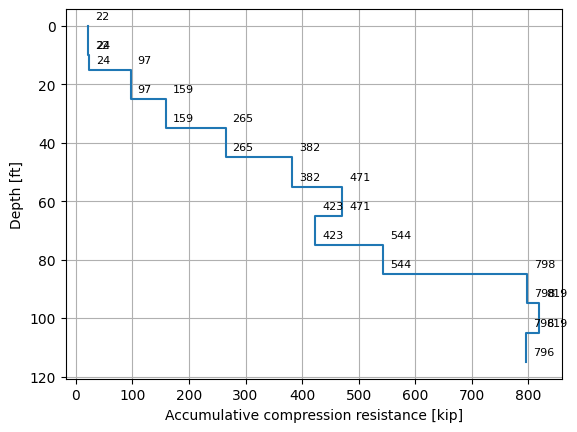

In [21]:
# piesewise plot
deep_foundation_obj.visualize_resistances_accumulative(target = "compression", style = "piecewise")

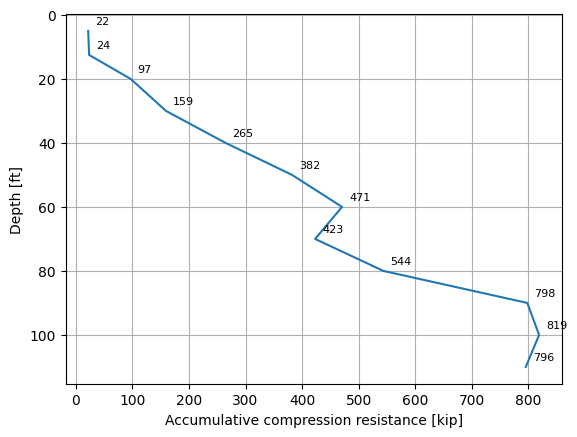

In [22]:
# midpoint plot
deep_foundation_obj.visualize_resistances_accumulative(target = "compression", style = "mid")

Test plotting uplift accumulative resistance

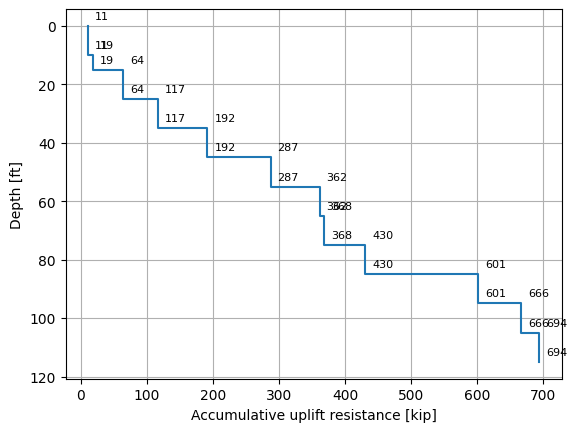

In [23]:
# piecewise plot
deep_foundation_obj.visualize_resistances_accumulative(target = "uplift", style = "piecewise")


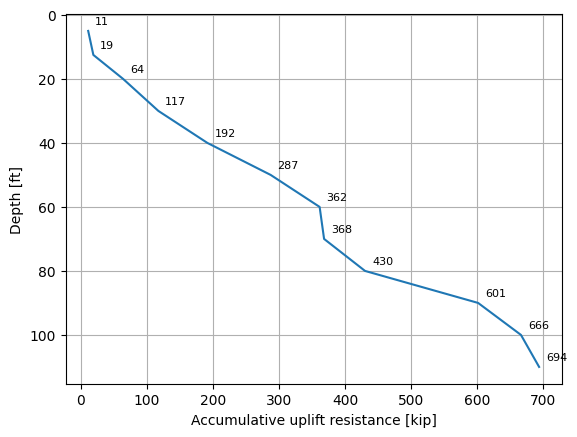

In [24]:
#midpoint plot
deep_foundation_obj.visualize_resistances_accumulative(target = "uplift", style = "mid")

In [25]:
# Test structural compression capacity
print("Each segment's structural capacity in compression is: ")
deep_foundation_obj.segments_structural_capacity_compression()

Each segment's structural capacity in compression is: 


[335899.0865218207,
 335899.0865218207,
 335899.0865218207,
 335899.0865218207,
 335899.0865218207,
 335899.0865218207,
 335899.0865218207,
 335899.0865218207,
 335899.0865218207,
 335899.0865218207,
 335899.0865218207,
 335899.0865218207]